# Abstract-Level Test Run: Cross-Provider Coding and Reliability

### Applying the Stage 2 coding scheme of the biopsychosocial chronic pain review to 100 PubMed records, once per model, with three providers

**Stijn Van Severen · Christopher Eccleston · Annick De Paepe · Maya Braun · Julie Dendauw · Jose Luis Socorro Cumplido · Geert Crombez**
Ghent University · OSF registration [10.17605/OSF.IO/T4FAM](https://doi.org/10.17605/OSF.IO/T4FAM)

---

This notebook runs the **abstract-level half** of the review pipeline end to end: it draws a
fresh sample from the registered operational PubMed query, applies the Stage 2 coding scheme
to every record with **three deliberately cheap large language models from three different
providers**, and quantifies how strongly the providers agree. The three models act as three
independent raters, so the run is a **cross-provider inter-rater reliability check** on the
coding scheme and on the code that applies it.

> **This is a test run of the instrument, not a finding about the literature.**
> The three models are low-cost stand-ins. In the real study the same workflow runs with
> state-of-the-art models, which is a one-line change in `bps_review/pilot/config.py`. What
> the numbers below describe is where the coding scheme is specified tightly enough that
> independent coders converge, and where it is not. That is precisely the evidence the expert
> evaluation of the coding schemes needs.

**The chain this notebook is the first half of**

```
operational PubMed query
        |
        v
100 abstracts  ---->  Stage 2 coding, 3 models, 300 API calls
        |
        v
consensus filter (majority vote)  ---->  candidate set
        |
        v
open-access retrieval  ---->  notebook 02: full-text coding, same 3 models
```

**What this notebook does**

1. Names the three models and says why these three.
2. Draws and describes the sample: 100 records from the operational query.
3. Sets out the coding scheme, and separates what is judged from what is derived.
4. Reports a defect this run exposed in the pipeline's prompt, and the fix.
5. Applies the scheme with every model and checks that the grid is complete.
6. Shows one abstract as all three models coded it.
7. Quantifies reliability per field, per model pair, and per open list.
8. Renders four multi-panel figures.
9. Builds the majority-vote consensus and exports the candidate set for notebook 02.
10. Reports the real cost of the run.

In [1]:
# --- Setup -------------------------------------------------------------------
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Make the package importable even without an editable install.
ROOT = Path.cwd()
while not (ROOT / "src" / "03_pipeline").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src" / "03_pipeline"))

from bps_review.pilot.analysis.reliability import build_reliability
from bps_review.pilot.coding.data import ensure_corpus, load_corpus
from bps_review.pilot.coding.runner import load_or_run, run_testrun
from bps_review.pilot.config import (
    DERIVED_FIELDS,
    FIELD_LABELS,
    LIST_FIELDS,
    RELIABILITY_FIELDS,
    TESTRUN_MODELS,
    codings_dir,
    corpus_manifest_json,
    figures_dir,
    reliability_dir,
)
from bps_review.pilot.pipeline import export_candidate_set
from bps_review.pilot.report import write_summary
from bps_review.pilot.visualization.figures import build_figures

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 170)
print(f"Repository root: {ROOT}")
print("Environment ready.")

Repository root: /Users/stijnvanseveren/PROJECTS/summer_2026/CROMBEZ_MAP/05_BPS_Review_Study
Environment ready.


## 1. The three coders

Three models, three providers, one identical instruction set. Using several providers rather
than several runs of one model is what makes the agreement informative: two samples from the
same model share its idiosyncrasies, while two different models share only what the coding
scheme actually specifies.

The three were selected on evidence rather than on preference. A cross-provider pilot on a
neighbouring review compared five cheap models on a full-text extraction task and ranked them
by how much of their quoted evidence could be found back in the source article. The three kept
here verified 99.9, 97.5, and 97.0 percent of their quotes; the two dropped verified about 90
percent. The same three are used in notebook 02, so the two stages stay comparable.

In [2]:
models_df = pd.DataFrame(
    [{"#": m.order, "Model": m.label, "OpenRouter id": m.openrouter_id, "Provider": m.provider}
     for m in TESTRUN_MODELS]
).set_index("#")
models_df

,Model,OpenRouter id,Provider
#,,,
1,DeepSeek-V4-Flash,deepseek/deepseek-v4-flash,DeepSeek
2,Nex-N2-Mini,nex-agi/nex-n2-mini,Nex AGI
3,Laguna-XS-2.1,poolside/laguna-xs-2.1,Poolside


## 2. The sample

The run starts where the review starts: the operational PubMed query from
`src/03_pipeline/config/search_queries.yaml`, inside the protocol's date window. The sampling
rule is deliberately simple and reproducible, so the sample can be described exactly and drawn
again: run the query sorted by publication date, drop records without a usable abstract
(an abstract-level scheme cannot be applied to a title alone), and keep the most recent 100.

Sorting by date rather than at random is a choice with a consequence worth stating: the sample
is the recent literature, not the whole 1977 to 2026 window the review covers. For a test of
the instrument that is an advantage, because recent records are more likely to be open access
and therefore more likely to survive into the full-text stage.

In [3]:
corpus = ensure_corpus()          # cached; pass force=True to draw a fresh sample
manifest = json.loads(corpus_manifest_json().read_text())

print(f"Query      : {manifest['query_label']}")
print(f"Window     : {manifest['date_window']['start']} to {manifest['date_window']['end']}")
print(f"Hits       : {manifest['total_query_hits']} records match the query")
print(f"Retrieved  : {manifest['candidates_retrieved']} for screening")
print(f"With an abstract of at least {manifest['min_abstract_chars']} characters: {manifest['with_usable_abstract']}")
print(f"Sample     : {manifest['sample_size']} records, {manifest['year_range'][0]} to {manifest['year_range'][1]}")
print(f"Of those, {manifest['with_pmcid']} carry a PubMed Central id, so a full text may be retrievable later.")

Query      : Operational PubMed query
Window     : 1977-01-01 to 2026-03-31
Hits       : 509 records match the query
Retrieved  : 220 for screening
With an abstract of at least 250 characters: 219
Sample     : 100 records, 2024 to 2026
Of those, 60 carry a PubMed Central id, so a full text may be retrievable later.


In [4]:
print(manifest["query_string"])
corpus[["record_id", "year", "journal", "title"]].head(8)

("biopsychosocial"[Title/Abstract] OR "bio-psycho-social"[Title/Abstract] OR "bio psycho social"[Title/Abstract]) AND ("chronic pain"[Title/Abstract] OR "persistent pain"[Title/Abstract]) AND Review[ptyp]


,record_id,year,journal,title
0,A001_42403485,2026,Frontiers in neuroscience,Acoustic stimulation in pain management: neurobiological mechanisms and clinical appli...
1,A002_42385067,2026,Ciencia & saude coletiva,Chronic pain self-management during the return to work process: an integrative review.
2,A003_42080121,2026,Frontiers in aging neuroscience,Myofascial pain in older adults: a geroscience-informed framework integrating precisio...
3,A004_41976799,2026,Journal of clinical medicine,Biopsychosocial Predictors of Pain Persistence and Pain Chronification in Temporomandi...
4,A005_41930351,2026,MedComm,Unraveling Chronic Pain: From Mechanisms and Risks to Diagnosis and Treatment.
5,A006_41897178,2026,"Healthcare (Basel, Switzerland)",Biopsychosocial and Cultural Determinants of Functioning and Healthcare Outcomes in Ch...
6,A007_41868689,2026,Pain reports,Acceptance of pain neuroscience education in chronic musculoskeletal pain conditions: ...
7,A008_41783653,2026,AJOG global reports,The influence of antenatal and pregnancy-related factors on recovery after childbirth:...


## 3. What the scheme codes, and what it derives

The Stage 2 scheme writes one coding bundle per record. Its fields fall into three kinds, and
keeping them apart is what makes the reliability numbers interpretable.

**Judged fields.** What kind of evidence synthesis this is, what its aim is, which ICD-11 pain
family it studies, whether it is relevant to the musculoskeletal review, what the
biopsychosocial model is actually doing in the abstract, whether each of the three domains
carries substantive content, whether a quality assessment is reported, and which provisional
typology the abstract signals. These are judgements, and disagreement between coders is real
disagreement.

**Derived fields.** `stage3_candidate` and `stage3_priority` are computed from the
musculoskeletal routing flag by a fixed rule, and `conceptual_problem_flags` is completed from
the coded domain and typology values. Their agreement is the agreement of the judgements they
read, not an independent judgement. Reporting them without saying so would inflate the picture,
so the tables below flag them.

**Open lists.** The psychological concepts and the theoretical frameworks the abstract names.
Two coders can both be right and still write different strings, so these are quantified with
set overlap rather than with a chance-corrected coefficient.

A principle the scheme is built on, and which the domain fields exist to enforce: **the word
biopsychosocial is never evidence of coverage.** A review can use the label in every paragraph
and still have no social content in it.

In [5]:
field_kinds = pd.DataFrame(
    [{"Field": field,
      "Label": FIELD_LABELS.get(field, field),
      "Kind": "derived from other fields" if field in DERIVED_FIELDS else "judged from the abstract"}
     for field in RELIABILITY_FIELDS]
    + [{"Field": field, "Label": FIELD_LABELS.get(field, field), "Kind": "open list (set overlap)"}
       for field in LIST_FIELDS]
)
field_kinds

,Field,Label,Kind
0,review_type,Review type,judged from the abstract
1,objective_category,Objective category,judged from the abstract
2,icd11_pain_category,ICD-11 pain category,judged from the abstract
3,musculoskeletal_flag,Musculoskeletal flag,judged from the abstract
4,bps_function,BPS function,judged from the abstract
5,quality_assessment_reported,Quality assessment,judged from the abstract
6,provisional_typology,Provisional typology,judged from the abstract
7,stage3_candidate,Stage 3 candidate,derived from other fields
8,bio_mentioned,Biological mention,judged from the abstract
9,psych_mentioned,Psychological mention,judged from the abstract


## 4. A defect this run exposed, and the fix

The first execution of this notebook produced a result that was too good to be true: perfect
agreement, Fleiss' kappa of exactly 1.00, on `bio_mentioned`, `psych_mentioned`,
`social_mentioned`, `musculoskeletal_flag`, and `quality_assessment_reported`. Three different
models from three providers do not agree perfectly on 100 abstracts about whether a review
carries substantive social content.

The cause was in the pipeline's Stage 2 prompt. It listed the value vocabularies
(`review_type_options`, `icd11_options`, and so on) but never named the fields the response had
to contain. The models answered with the fields whose option lists they could see and silently
omitted the other five. The deterministic repair layer, which exists to fix a malformed field,
then filled those five from the lexical rule-based coder. The output looked like a complete
structured coding, was labelled `llm_structured`, and was in fact keyword matching for the
review's core RQ2 variables.

**The fix.** The prompt now carries an explicit field specification: every field of the
validated schema, with its operational anchor and its allowed values, plus an output contract
that says every key must be present. A test
(`test_abstract_prompt_names_every_schema_field`) asserts that the specification and the
schema cannot drift apart again.

This is what a test run is for. The defect was invisible in the outputs of the earlier run
that produced the current manuscript, and it is exactly the kind of thing that a reliability
check surfaces and a spot check does not.

In [6]:
from bps_review.extraction.llm_stage2 import FIELD_SPECIFICATION, Stage2StructuredRecord

print(f"Fields the schema validates : {len(Stage2StructuredRecord.model_fields)}")
print(f"Fields the prompt specifies : {len(FIELD_SPECIFICATION)}")
print(f"Identical set               : {set(Stage2StructuredRecord.model_fields) == set(FIELD_SPECIFICATION)}")
print()
print("The five fields that were silently rule-based before the fix:")
for field in ("bio_mentioned", "psych_mentioned", "social_mentioned",
              "musculoskeletal_flag", "quality_assessment_reported"):
    print(f"  {field:28s} {FIELD_SPECIFICATION[field]['instruction'][:96]}...")

Fields the schema validates : 17
Fields the prompt specifies : 17
Identical set               : True

The five fields that were silently rule-based before the fix:
  bio_mentioned                Whether the abstract carries substantive biological content: anatomy, physiology, pathophysiolog...
  psych_mentioned              Whether the abstract carries substantive psychological content: cognition, affect, behaviour, be...
  social_mentioned             Whether the abstract carries substantive social content: work and occupational context, family a...
  musculoskeletal_flag         Whether this record is relevant to the musculoskeletal chronic pain review. 'yes' when a musculo...
  quality_assessment_reported  Whether the abstract reports a risk-of-bias or quality assessment (AMSTAR, GRADE, Cochrane RoB, ...


## 5. Applying the scheme

Every model codes every abstract through exactly the same structured-JSON path the main
pipeline uses, so what is under test is the pipeline's own coding logic rather than a notebook
copy of it.

One record per request rather than a batch. It makes the call count equal to the coding count
(100 records x 3 models = 300 calls), it removes any chance that one record in a batch
influences the coding of another, and abstracts are short enough that the cost difference is
negligible. Records are coded concurrently through a `ThreadPoolExecutor` with 16 workers per
model, and the three models run in parallel, so the whole grid finishes in one pass. Every
attempt carries a hard wall-clock timeout, because a provider that trickles bytes never trips
the socket read timeout.

Set `FORCE_RERUN = True` to call the API again. Otherwise the cached long table is loaded.

In [7]:
FORCE_RERUN = False   # True re-codes all 100 abstracts with all 3 models (300 API calls)

long_df = run_testrun() if FORCE_RERUN else load_or_run(force=False)
print(f"{len(long_df)} codings = {long_df['record_id'].nunique()} abstracts x {long_df['model_label'].nunique()} models")
long_df[["record_id", "model_label", "review_type", "musculoskeletal_flag",
         "bio_mentioned", "psych_mentioned", "social_mentioned", "provisional_typology"]].head(6)

300 codings = 100 abstracts x 3 models


,record_id,model_label,review_type,musculoskeletal_flag,bio_mentioned,psych_mentioned,social_mentioned,provisional_typology
0,A001_42403485,DeepSeek-V4-Flash,narrative or expert review,unclear,yes,no,no,pseudo-bps or partial signal
1,A002_42385067,DeepSeek-V4-Flash,integrative review,unclear,no,yes,yes,pseudo-bps or partial signal
2,A003_42080121,DeepSeek-V4-Flash,narrative or expert review,yes,yes,yes,yes,multifactorial signal
3,A004_41976799,DeepSeek-V4-Flash,systematic review,yes,no,yes,no,pseudo-bps or partial signal
4,A005_41930351,DeepSeek-V4-Flash,systematic review,unclear,yes,no,no,pseudo-bps or partial signal
5,A006_41897178,DeepSeek-V4-Flash,integrative review,unclear,yes,yes,yes,potential integrative signal


In [8]:
# Integrity: is the grid complete, and did every cell really come from the model?
run_manifest = json.loads((codings_dir() / "run_manifest.json").read_text())
grid = long_df.groupby("model_label")["record_id"].nunique()

print("Codings per model:", grid.to_dict())
print("Grid complete    :", bool(len(long_df) == run_manifest["n_abstracts"] * run_manifest["n_models"]))
print("Coding methods   :", run_manifest["coding_method_counts"])
print("API calls        :", run_manifest["n_api_calls"])
print()
print("A coding_method of 'llm_structured' means the model returned a usable response.")
print("'rule_based_fallback' would mean the deterministic coder had to stand in, and would be visible here.")

Codings per model: {'DeepSeek-V4-Flash': 100, 'Laguna-XS-2.1': 100, 'Nex-N2-Mini': 100}
Grid complete    : True
Coding methods   : {'llm_structured': 300}
API calls        : 300

A coding_method of 'llm_structured' means the model returned a usable response.
'rule_based_fallback' would mean the deterministic coder had to stand in, and would be visible here.


## 6. One abstract, three coders

Before any aggregate, it is worth looking at a single record as the three models coded it. This
is where agreement and disagreement become concrete: the same 250 words, read three times.

In [9]:
example_id = sorted(long_df["record_id"].unique())[2]
example = corpus[corpus["record_id"] == example_id].iloc[0]

print(f"{example['record_id']}  ({example['year']}, {example['journal']})")
print(example["title"])
print()
print(example["abstract"][:900] + " ...")

A003_42080121  (2026, Frontiers in aging neuroscience)
Myofascial pain in older adults: a geroscience-informed framework integrating precision geriatrics and digital therapeutics.

Myofascial pain syndrome (MPS) in the elderly is a significant contributor to chronic pain and functional decline, driven by a unique set of age-related pathophysiological challenges. Core geroscience principles-including sarcopenia, inflammaging, and cellular senescence-converge to create a state of heightened central sensitization that amplifies pain. Traditional pharmacotherapy is fraught with risks in this population due to polypharmacy and vulnerability to adverse effects, with many common analgesics discouraged by geriatric guidelines. This review proposes an innovative biopsychosocial framework integrating precision geriatrics and digital therapeutics to address these challenges. Precision geriatrics employs multidimensional assessment tools (e.g., ultrasonography, frailty indices) to phenotype patien

In [10]:
shown = ["review_type", "objective_category", "icd11_pain_category", "musculoskeletal_flag",
         "bps_function", "bio_mentioned", "psych_mentioned", "social_mentioned",
         "provisional_typology", "stage3_candidate", "stage3_priority"]
(long_df[long_df["record_id"] == example_id]
 .set_index("model_label")[shown]
 .T.rename_axis("field"))

model_label,DeepSeek-V4-Flash,Nex-N2-Mini,Laguna-XS-2.1
field,,,
review_type,narrative or expert review,narrative or expert review,systematic review
objective_category,conceptual,clinical,conceptual
icd11_pain_category,chronic secondary musculoskeletal pain,chronic secondary musculoskeletal pain,chronic secondary musculoskeletal pain
musculoskeletal_flag,yes,yes,yes
bps_function,intervention rationale,organizing principle,organizing principle
bio_mentioned,yes,yes,yes
psych_mentioned,yes,yes,yes
social_mentioned,yes,yes,yes
provisional_typology,multifactorial signal,multifactorial signal,potential integrative signal


## 7. Cross-provider reliability

Four coefficients, because each answers a different question.

- **Observed agreement** is the share of records on which two coders wrote the same value. It
  is the most intuitive number and the most misleading one on its own: on a field where 90
  percent of records take the same value, two coders who both always guess that value agree 90
  percent of the time while adding nothing.
- **Fleiss' kappa** corrects for exactly that, over all three raters at once. Landis and Koch
  read 0.41 to 0.60 as moderate, 0.61 to 0.80 as substantial, above 0.80 as almost perfect.
- **Krippendorff's alpha** answers the same question with a different estimator; when the two
  diverge, the field usually has a rare category.
- **The unanimous rate** is the share of records on which all three coders agree, which is what
  a human adjudicator would experience as "no discussion needed".

In [11]:
results = build_reliability(long_df, write=True)
field_rel = results["field_reliability"].copy()
field_rel["derived"] = field_rel["field"].isin(DERIVED_FIELDS).map({True: "yes", False: ""})
field_rel[["field_label", "group", "derived", "n_categories", "mean_pairwise_agreement",
           "unanimous_rate", "fleiss_kappa", "krippendorff_alpha", "landis_koch"]].round(3)

,field_label,group,derived,n_categories,mean_pairwise_agreement,unanimous_rate,fleiss_kappa,krippendorff_alpha,landis_koch
0,Review type,nominal,,9,0.817,0.74,0.708,0.709,Substantial
1,Objective category,nominal,,5,0.723,0.60,0.512,0.514,Moderate
2,ICD-11 pain category,nominal,,9,0.847,0.78,0.759,0.759,Substantial
3,Musculoskeletal flag,nominal,,3,0.723,0.63,0.568,0.569,Moderate
4,BPS function,nominal,,9,0.497,0.34,0.345,0.348,Fair
5,Quality assessment,nominal,,3,0.973,0.96,0.918,0.919,Almost perfect
6,Provisional typology,nominal,,4,0.577,0.43,0.327,0.329,Fair
7,Stage 3 candidate,nominal,yes,2,0.940,0.91,0.735,0.736,Substantial
8,Biological mention,domain,,2,0.787,0.68,0.495,0.497,Moderate
9,Psychological mention,domain,,2,0.853,0.78,0.536,0.537,Moderate


**Reading the table.** The pattern is the interesting part, not the average. Fields that ask
what a paper *is* score highest: the ICD-11 pain family and the review design are close to
substantial agreement, because an abstract usually states them. Fields that ask what a paper
*does* score lowest, and the two weakest are the ones that carry the review's own argument:
`bps_function` (what work the biopsychosocial label is doing) and `provisional_typology` (what
kind of biopsychosocial usage this is). That is not a defect of the models. It is a
measurement of how much interpretive room the current value definitions leave, and it is the
single most useful thing this run has to say to the expert evaluation.

The three domain-mention fields sit in between, and they now differ across providers, which is
what they should do after the prompt fix.

In [12]:
summary = results["summary"]
print(f"Abstracts                 : {summary['n_abstracts']}")
print(f"Models                    : {summary['n_models']}")
print(f"Mean Fleiss' kappa        : {summary['mean_fleiss_kappa']:.3f}")
print(f"Mean Krippendorff's alpha : {summary['mean_krippendorff_alpha']:.3f}")
print(f"Mean observed agreement   : {summary['mean_pairwise_agreement']:.1%}")
print(f"Mean unanimous rate       : {summary['mean_unanimous_rate']:.1%}")
print()
most, least = summary["most_agreeing_pair"], summary["least_agreeing_pair"]
print(f"Closest pair   : {most['models'][0]} and {most['models'][1]} ({most['agreement']:.1%})")
print(f"Most distant   : {least['models'][0]} and {least['models'][1]} ({least['agreement']:.1%})")
print(f"Unanimous on the Stage 3 candidacy call: {summary['candidate_unanimous_items']} of {summary['n_abstracts']} abstracts")

Abstracts                 : 100
Models                    : 3
Mean Fleiss' kappa        : 0.604
Mean Krippendorff's alpha : 0.605
Mean observed agreement   : 77.9%
Mean unanimous rate       : 69.2%

Closest pair   : DeepSeek-V4-Flash and Nex-N2-Mini (82.0%)
Most distant   : DeepSeek-V4-Flash and Laguna-XS-2.1 (75.3%)
Unanimous on the Stage 3 candidacy call: 91 of 100 abstracts


### The open lists

The concepts and frameworks a coder extracts are an open set, so kappa is the wrong
instrument: a coder who writes `pain catastrophizing` and one who writes `catastrophizing` have
not disagreed about the paper. Set overlap (Jaccard) over normalized labels asks the question
that can be answered: of everything either coder found, how much did they both find.

In [13]:
results["list_overlap"][["field_label", "mean_pairwise_jaccard", "distinct_labels_total",
                         "items_with_a_shared_label",
                         *[c for c in results["list_overlap"].columns if c.startswith("mean_items_")]]].round(3)

,field_label,mean_pairwise_jaccard,distinct_labels_total,items_with_a_shared_label,mean_items_DeepSeek-V4-Flash,mean_items_Nex-N2-Mini,mean_items_Laguna-XS-2.1
0,Psychological concepts,0.555,263,68,2.95,3.41,2.62
1,Theoretical frameworks,0.470,87,41,1.07,1.22,0.99
2,Conceptual problems,0.441,7,50,2.41,2.28,1.55


### How the models differ

Agreement says how often two coders match. It does not say which way each coder leans. A model
that flags every record as musculoskeletal and one that flags none can produce a respectable
kappa on other fields while disagreeing completely about the corpus.

In [14]:
results["per_model_behavior"].round(3)

,model_label,provider,candidate_yes_rate,msk_yes_rate,integrative_signal_rate,multifactorial_rate,bio_rate,psych_rate,social_rate,mean_domain_count,mean_concepts,mean_frameworks,structured_share
0,DeepSeek-V4-Flash,DeepSeek,0.89,0.48,0.15,0.13,0.60,0.74,0.49,1.83,2.95,1.07,1.0
1,Nex-N2-Mini,Nex AGI,0.88,0.36,0.18,0.21,0.79,0.86,0.60,2.25,3.41,1.22,1.0
2,Laguna-XS-2.1,Poolside,0.84,0.34,0.49,0.05,0.70,0.81,0.54,2.05,2.62,0.99,1.0


## 8. Figures

Four multi-panel figures, written to `src/05_test_runs/tests/01_pilot_abstract/04_figures/`.

In [15]:
figure_paths = build_figures(long_df, results)
for path in figure_paths:
    print(path.name)

01_field_reliability_2x2.png
02_pairwise_agreement.png
03_per_model_behavior.png
04_consensus_profile.png


### Figure 1: reliability by field

Panel A is the headline: chance-corrected agreement per coded field, coloured by the Landis and
Koch band, with the band boundaries drawn in. Panel B repeats it with Krippendorff's alpha.
Panel C is raw observed agreement, and the distance between C and A is the amount of agreement
that was chance. Panel D is the unanimous rate.

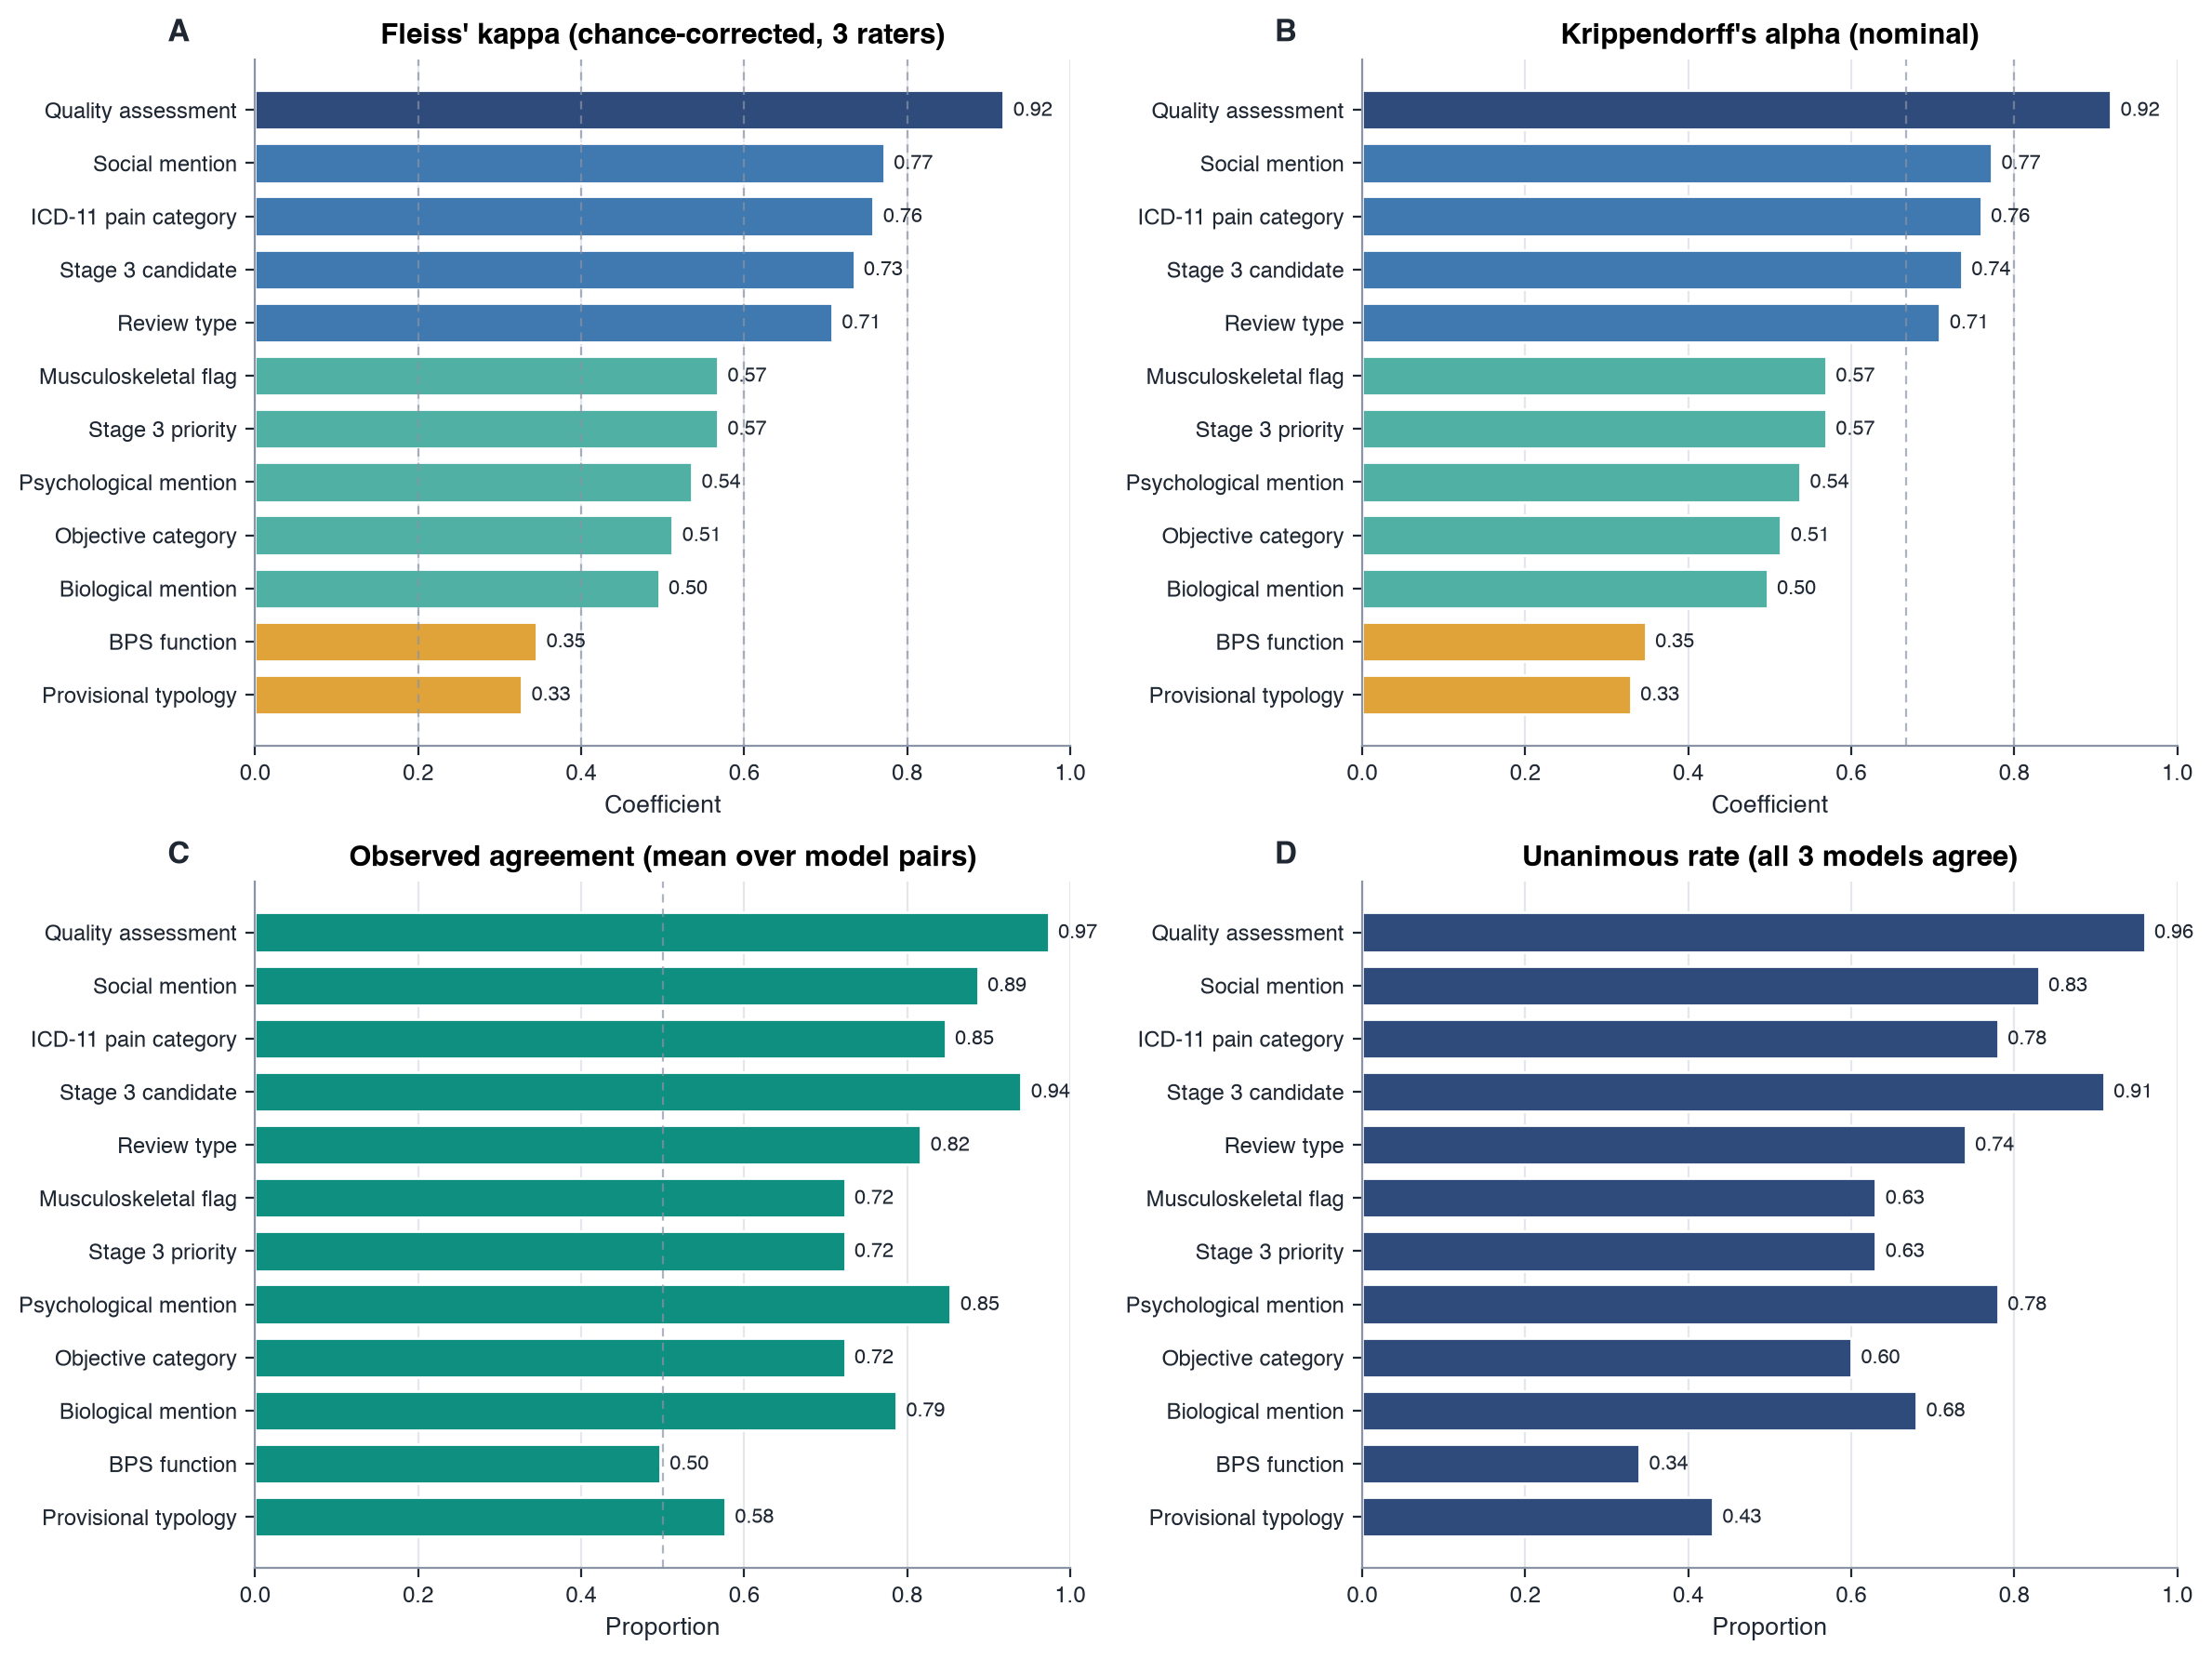

In [16]:
display(Image(filename=str(figures_dir() / "01_field_reliability_2x2.png")))

### Figure 2: agreement between providers

Panels A and B are the model-by-model matrices, observed and chance-corrected. Panel C collapses
each row into one number, the mean agreement of a model with the other two, which says which
provider is closest to the centre of the group. Panel D shows how deeply the three models back
the Stage 3 candidacy call: a bar at "3 vs 0" is a record no human would need to adjudicate.

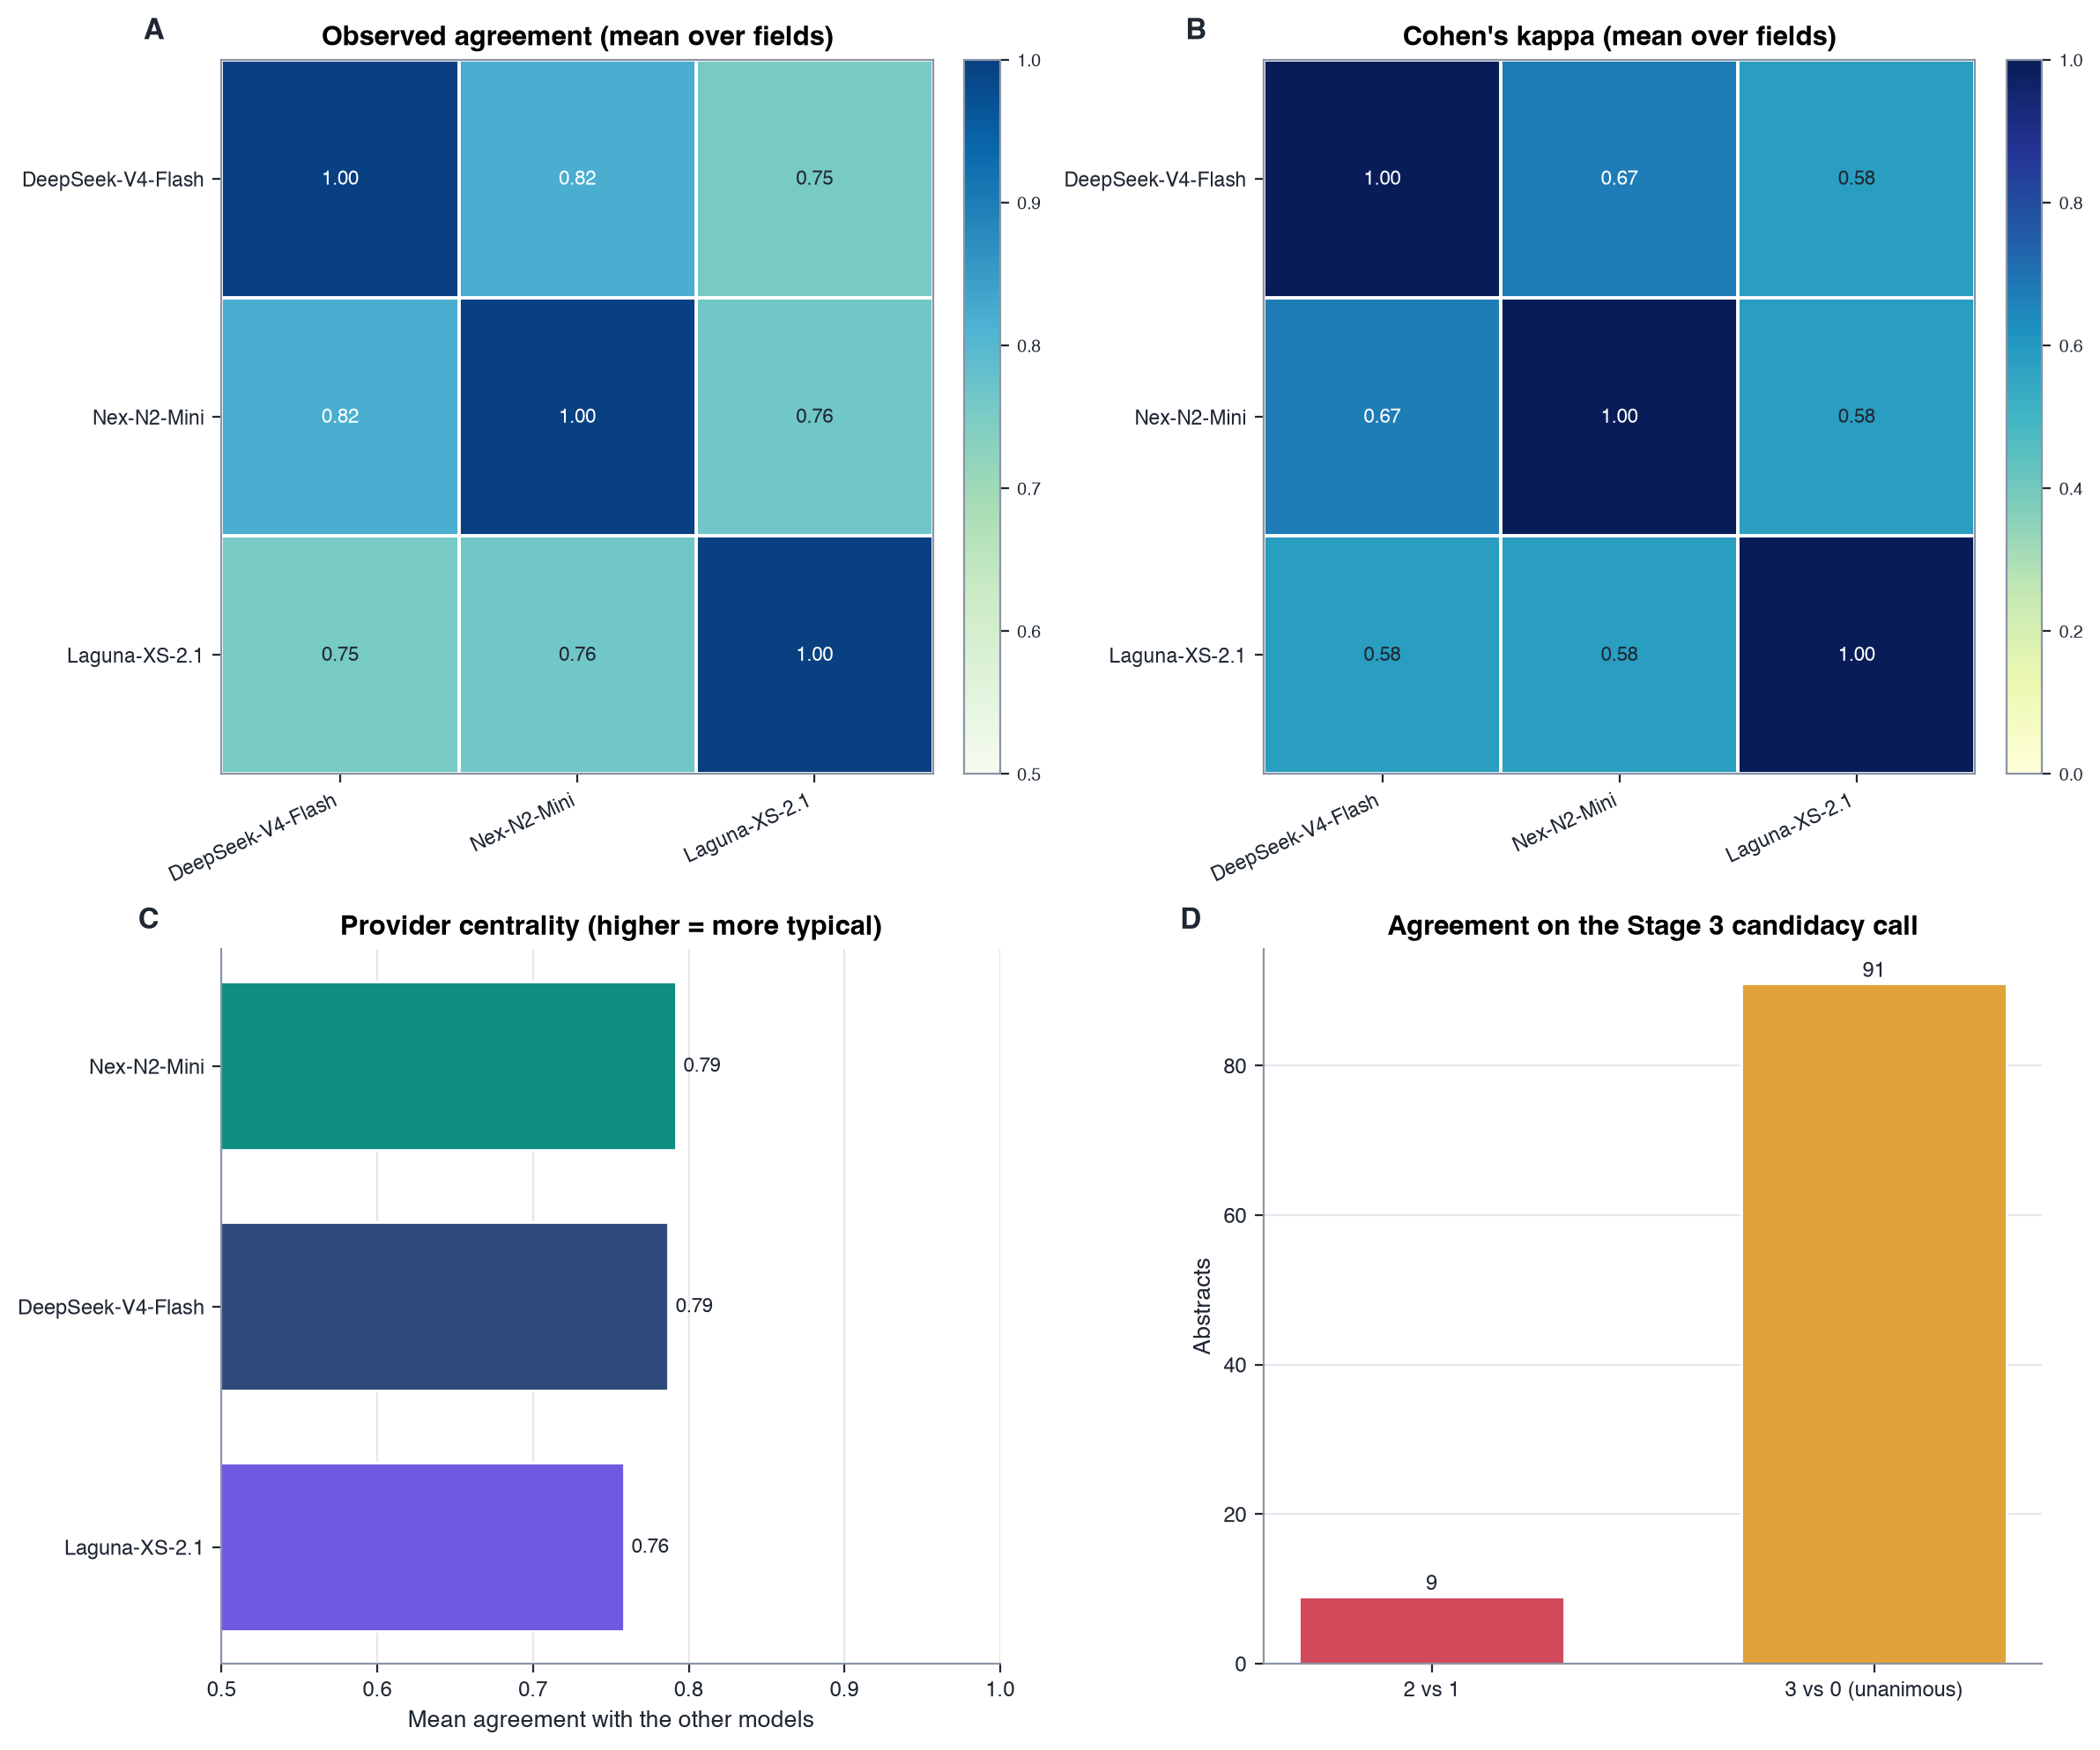

In [17]:
display(Image(filename=str(figures_dir() / "02_pairwise_agreement.png")))

### Figure 3: how the models code differently

Panel A gives the domain-mention rate per model per domain, which is the clearest picture of
leniency: the same 100 abstracts, three different readings of how much biology, psychology, and
social content they carry. Panels B and C are the typology and routing profiles. Panel D shows
how much each model extracts on the open lists.

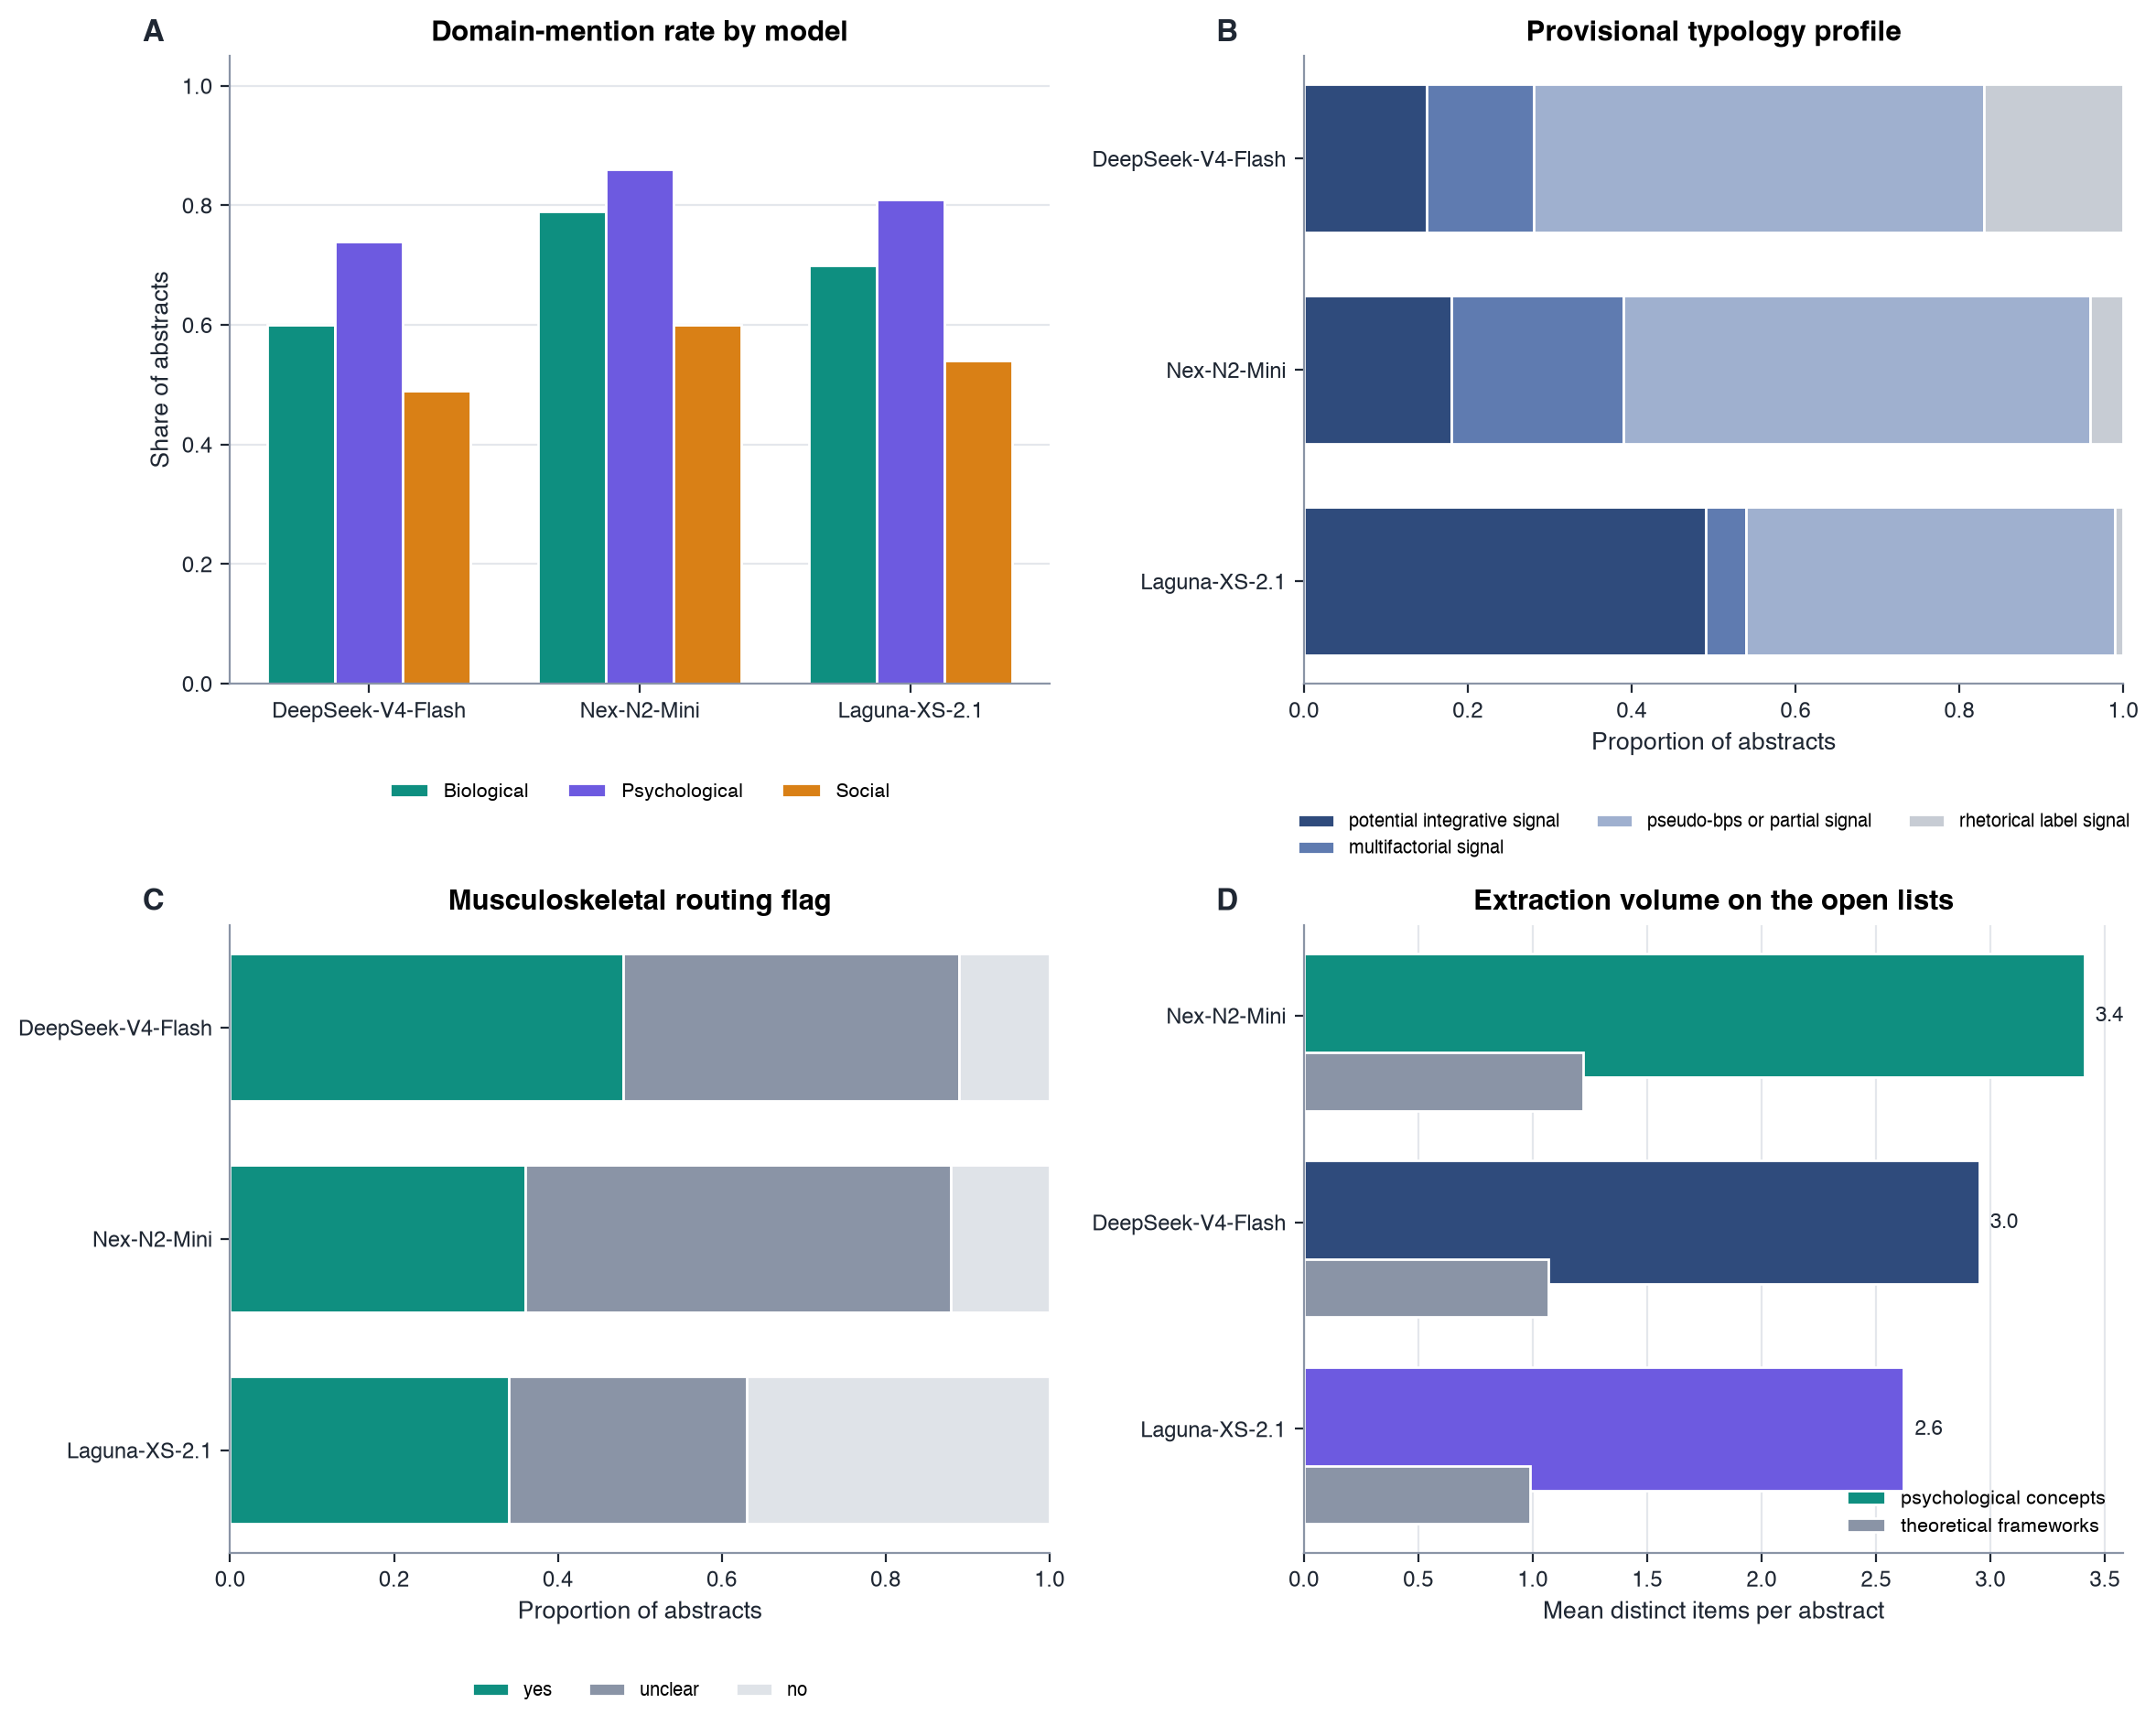

In [18]:
display(Image(filename=str(figures_dir() / "03_per_model_behavior.png")))

### Figure 4: the consensus picture

What the corpus looks like once the three codings are collapsed by majority vote, plus the
reliability overview by field group and the set overlap on the open lists.

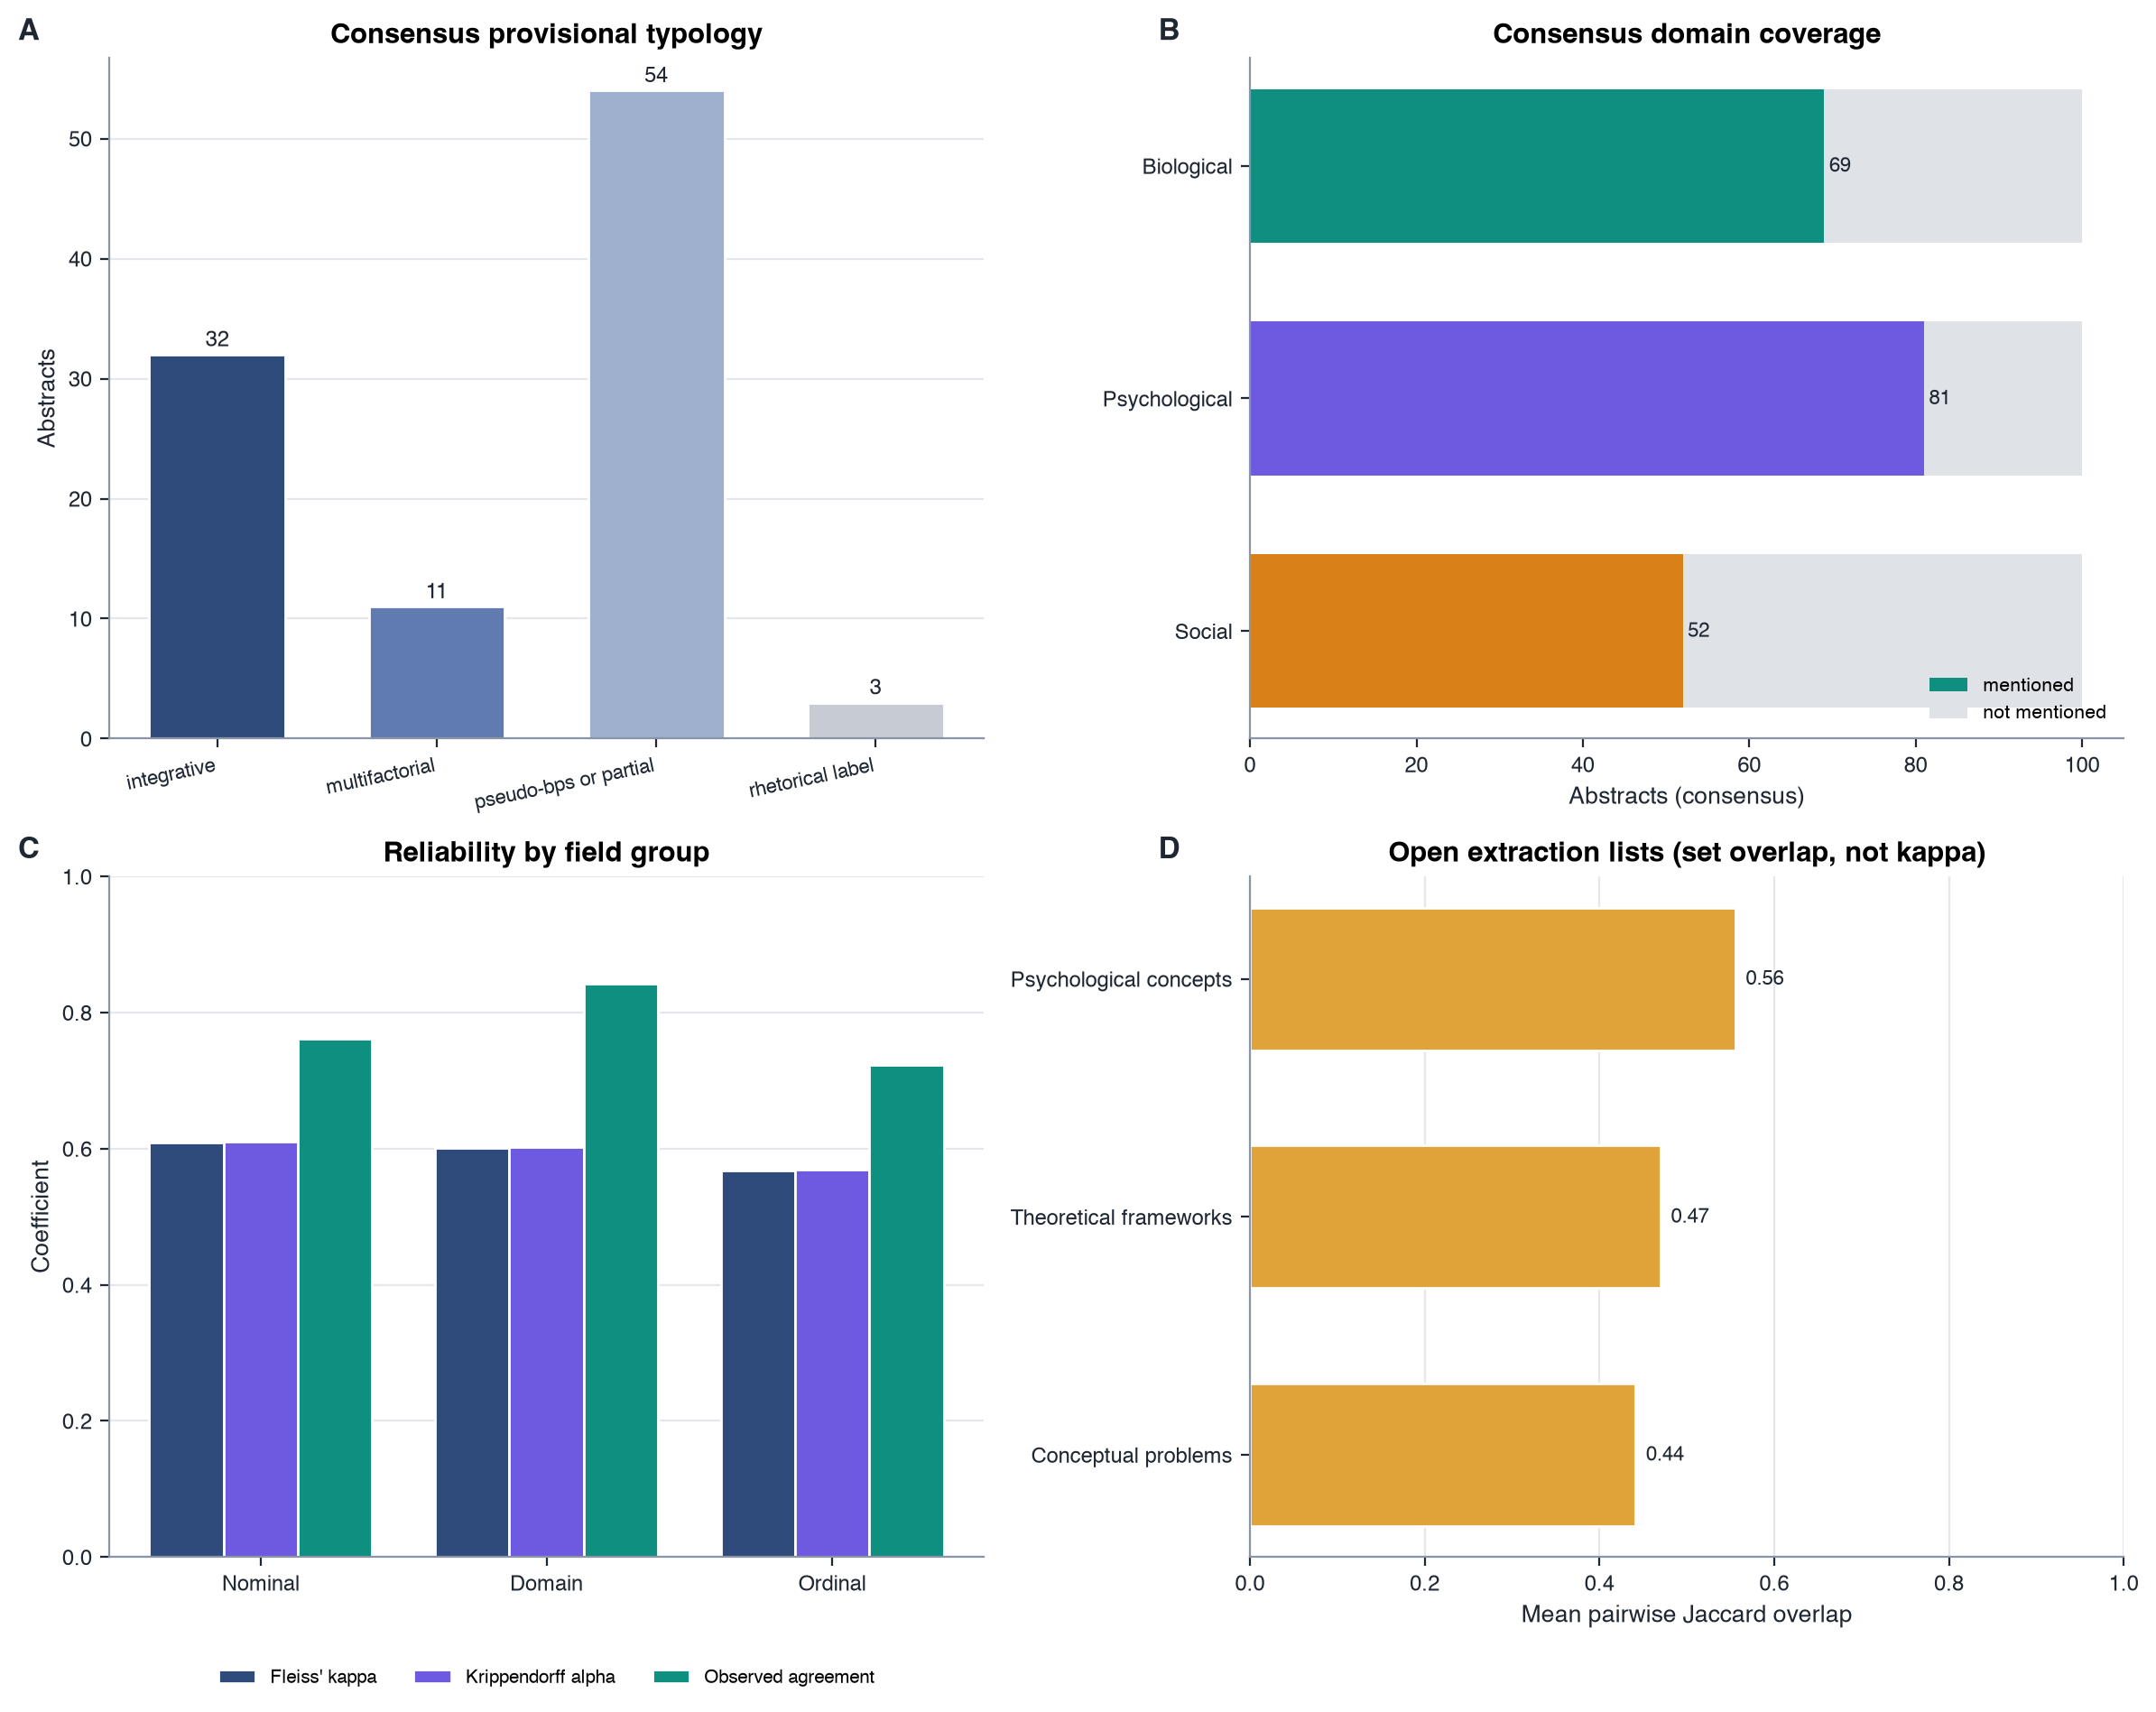

In [19]:
display(Image(filename=str(figures_dir() / "04_consensus_profile.png")))

## 9. Consensus, and the hand-off to the full-text stage

The consensus coding takes the majority value per field per record, resolving a three-way tie
toward the more conservative value. It is not a better coding than any single model's: it is the
coding a human adjudicator would start from, with the disagreements already located.

The records the consensus carries forward become the input to notebook 02.

In [20]:
consensus = results["consensus"]
print("Consensus provisional typology:")
print(consensus["provisional_typology"].value_counts().to_string())
print()
print("Consensus domain coverage:")
for field in ("bio_mentioned", "psych_mentioned", "social_mentioned"):
    n = int((consensus[field] == "yes").sum())
    print(f"  {FIELD_LABELS[field]:24s} {n:3d} of {len(consensus)} ({n / len(consensus):.0%})")
print()
print("Number of domains substantively present, per abstract:")
print(consensus["n_domains_consensus"].value_counts().sort_index().to_string())

Consensus provisional typology:
provisional_typology
pseudo-bps or partial signal    54
potential integrative signal    32
multifactorial signal           11
rhetorical label signal          3

Consensus domain coverage:
  Biological mention        69 of 100 (69%)
  Psychological mention     81 of 100 (81%)
  Social mention            52 of 100 (52%)

Number of domains substantively present, per abstract:
n_domains_consensus
0     4
1    28
2    30
3    38


In [21]:
candidates = export_candidate_set(consensus, corpus)
print(f"{len(candidates)} of {len(corpus)} abstracts are carried forward to the full-text stage.")
print(candidates["stage3_priority"].value_counts().to_string())
print()
with_pmc = int((candidates["pmcid"].astype(str).str.strip() != "").sum())
print(f"{with_pmc} of them carry a PubMed Central id, so notebook 02 can try to retrieve a full text.")
candidates.head(6)

88 of 100 abstracts are carried forward to the full-text stage.
stage3_priority
high      45
medium    42
low        1

53 of them carry a PubMed Central id, so notebook 02 can try to retrieve a full text.


,record_id,pmid,pmcid,doi,title,journal,year,stage3_candidate,stage3_priority,candidate_consensus_depth,musculoskeletal_flag,icd11_pain_category,provisional_typology,bio_mentioned,psych_mentioned,social_mentioned,n_domains_consensus
2,A003_42080121,42080121,PMC13128561,10.3389/fnagi.2026.1806386,Myofascial pain in older adults: a geroscience-informed framework integrating precisio...,Frontiers in aging neuroscience,2026,yes,high,3,yes,chronic secondary musculoskeletal pain,multifactorial signal,yes,yes,yes,3
3,A004_41976799,41976799,PMC13073292,10.3390/jcm15072498,Biopsychosocial Predictors of Pain Persistence and Pain Chronification in Temporomandi...,Journal of clinical medicine,2026,yes,high,3,yes,chronic secondary headache or orofacial pain,pseudo-bps or partial signal,yes,yes,no,2
6,A007_41868689,41868689,PMC13004225,10.1097/PR9.0000000000001420,Acceptance of pain neuroscience education in chronic musculoskeletal pain conditions: ...,Pain reports,2026,yes,high,3,yes,chronic secondary musculoskeletal pain,potential integrative signal,yes,yes,yes,3
12,A013_41492309,41492309,PMC12765098,10.1016/j.ocarto.2025.100725,Biopsychosocial predictive factors for developing chronic postsurgical pain after hip ...,Osteoarthritis and cartilage open,2026,yes,high,3,yes,chronic postsurgical or posttraumatic pain,multifactorial signal,yes,yes,yes,3
14,A015_41371390,41371390,,10.1016/j.joca.2025.12.001,Sympathosensory interactions - Possible relevance in osteoarthritis.,Osteoarthritis and cartilage,2026,yes,high,3,yes,chronic secondary musculoskeletal pain,pseudo-bps or partial signal,yes,yes,no,2
18,A019_41058307,41058307,PMC12705301,10.1111/joor.70074,Self-Management Therapies for Temporomandibular Disorders-Evidence From Systematic Rev...,Journal of oral rehabilitation,2026,yes,high,3,yes,chronic secondary headache or orofacial pain,pseudo-bps or partial signal,yes,yes,no,2


## 10. Cost, outputs, and reproducibility

Everything the run produced, and what it cost.

In [22]:
usage = run_manifest["token_usage_total"]
print(f"API calls    : {run_manifest['n_api_calls']}")
print(f"Tokens       : {usage['total_tokens']:,}")
print(f"Cost         : ${usage['cost_usd']:.3f}")
print()
for label, values in run_manifest["token_usage_by_model"].items():
    print(f"  {label:20s} {values['total_tokens']:>9,} tokens   ${values['cost_usd']:.4f}")

API calls    : 300
Tokens       : 1,375,595
Cost         : $0.131

  DeepSeek-V4-Flash      398,802 tokens   $0.0633
  Laguna-XS-2.1          366,814 tokens   $0.0243
  Nex-N2-Mini            609,979 tokens   $0.0434


In [23]:
summary_text = write_summary(long_df, results, corpus)
base = ROOT / "src" / "05_test_runs" / "tests" / "01_pilot_abstract"
for path in sorted(base.rglob("*")):
    if path.is_file() and path.suffix in {".csv", ".json", ".png", ".md", ".log"}:
        print(f"{path.relative_to(base)}")

01_abstracts/articles.csv
01_abstracts/corpus_manifest.json
02_model_codings/all_model_codings_long.csv
02_model_codings/by_model/01_deepseek_v4_flash.csv
02_model_codings/by_model/02_nex_n2_mini.csv
02_model_codings/by_model/03_laguna_xs_2_1.csv
02_model_codings/run.log
02_model_codings/run_manifest.json
03_reliability/01_field_reliability.csv
03_reliability/02_pairwise_percent_agreement.csv
03_reliability/03_pairwise_cohen_kappa.csv
03_reliability/04_per_model_behavior.csv
03_reliability/05_consensus_codings.csv
03_reliability/06_candidate_depth_distribution.csv
03_reliability/07_list_overlap.csv
03_reliability/reliability_summary.json
04_figures/01_field_reliability_2x2.png
04_figures/02_pairwise_agreement.png
04_figures/03_per_model_behavior.png
04_figures/04_consensus_profile.png
05_fulltext_candidate_set.csv
TEST_RUN_SUMMARY.md


### Takeaways

1. **The workflow runs end to end and is cheap.** 300 codings from 300 API calls, no failures,
   for about 13 US cents. Cost is not a constraint on running this with far stronger models.

2. **Agreement is field-dependent, and the pattern is the finding.** Descriptive fields the
   abstract states outright reach substantial agreement. The two fields that carry the review's
   own argument, what work the biopsychosocial label is doing and which typology the abstract
   signals, are the least reliable. Those value definitions are where the expert evaluation
   should concentrate.

3. **The domain fields are now measured rather than assumed.** Before the prompt fix they were
   lexical rules wearing the label of a model coding. This matters beyond the test run: the
   same defect was present in the pipeline that produced the current manuscript.

4. **A derived verdict is only as good as the judgement under it.** `stage3_candidate` scores
   well because it is a rule applied to `musculoskeletal_flag`, which scores moderately. The
   filter is auditable and consistent; it is not independent evidence.

5. **The open lists agree more than the typology does.** Coders converge better on which
   concepts a paper names than on what kind of biopsychosocial usage it represents, which
   points at the typology definition rather than at the coders.

**To reproduce**

```bash
python -m bps_review run-abstract-testrun --force-corpus --force-coding
```

or set `FORCE_RERUN = True` in section 5 and run this notebook top to bottom. The models are
configured in `src/03_pipeline/bps_review/pilot/config.py`; replacing them with
state-of-the-art models is a single edit to `TESTRUN_MODELS`.

**Next**: [`02_fulltextlevel_testrun.ipynb`](02_fulltextlevel_testrun.ipynb) takes the candidate
set exported above, retrieves the open-access full texts, and applies the Stage 3 deep coding
scheme with the same three models.